# explorative data analysis

In [1]:
# import modules 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
pd.set_option('display.float_format', '{:.2f}'.format)
from pathlib import Path



In [2]:
# load dataset

df = pd.read_csv(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.csv"
)

print(df.shape)
# df.head()


(57529, 30)


In [72]:
df.describe()

,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,follow_up_prompts,needs_follow_up,...,question_count,orthographic_error_rate,topic,topic_prob,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost
count,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,...,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00,57529.00
mean,176.59,496.31,16.62,8.31,737.40,4090.66,4828.05,7.52,7.33,0.73,...,0.60,0.05,0.43,0.56,0.76,0.56,0.40,24647.12,9.77,496.31
std,802.25,903.69,36.51,18.25,3076.31,10372.56,11669.88,1.35,18.43,0.44,...,2.96,0.07,4.37,0.31,0.14,0.31,0.49,8167.03,1.41,903.69
min,2.00,1.00,2.00,1.00,5.00,1.00,9.00,2.30,0.00,0.00,...,0.00,0.00,-1.00,0.00,0.37,0.00,0.00,51.00,3.95,1.00
25%,16.00,155.00,2.00,1.00,47.00,542.00,698.00,6.55,0.00,0.00,...,0.00,0.00,-1.00,0.30,0.66,0.30,0.00,22662.00,10.03,155.00
50%,34.00,329.00,6.00,3.00,142.00,1418.00,1763.00,7.48,2.00,1.00,...,0.00,0.02,-1.00,0.56,0.76,0.56,0.00,30054.00,10.31,329.00
75%,112.00,587.00,16.00,8.00,473.00,3762.00,4537.00,8.42,7.00,1.00,...,1.00,0.08,0.00,0.80,0.87,0.80,1.00,30054.00,10.31,587.00
max,79821.00,76828.00,972.00,486.00,168177.00,358980.00,360095.00,12.79,547.00,1.00,...,261.00,1.00,35.00,1.00,1.18,1.00,1.00,30054.00,10.31,76828.00


<Axes: >

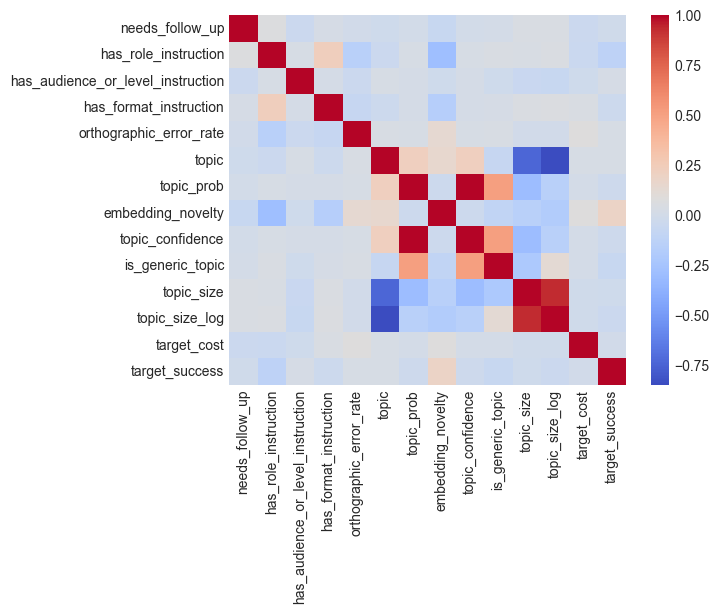

In [35]:
# correlations

sns.heatmap(df[['needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
        'orthographic_error_rate', 'topic', 'topic_prob',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success']].corr(), cmap="coolwarm")

In [36]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success'],
      dtype='str')

# features

### structure features

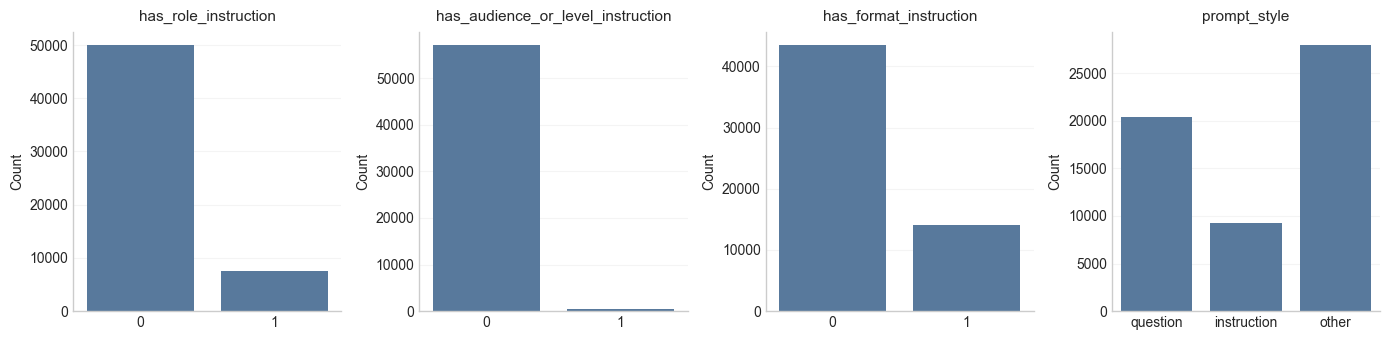

In [37]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes = axes.flatten()

prompt_design_features = [
    'has_role_instruction',
    'has_audience_or_level_instruction',
    'has_format_instruction',
    'prompt_style'
]

for i, feature in enumerate(prompt_design_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=axes[i],
        color="#4C78A8"
    )

    axes[i].set_title(feature, fontsize=11, pad=8)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    axes[i].grid(axis="y", alpha=0.2)
    axes[i].grid(axis="x", visible=False)

    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()


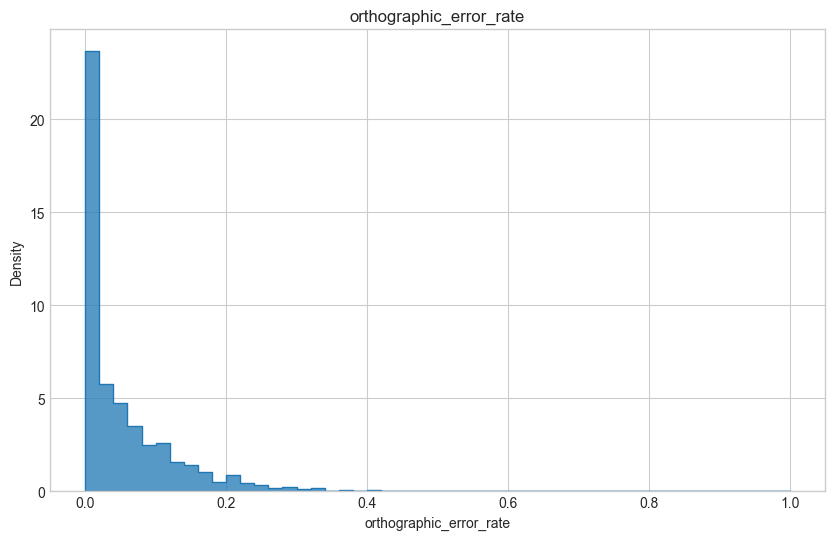

In [38]:
plot_data = df[['orthographic_error_rate']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="orthographic_error_rate",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('orthographic_error_rate')
plt.xlabel('orthographic_error_rate')
plt.ylabel("Density")

plt.show()

In [39]:
OER = 0.40

outliers_oer = df[df["orthographic_error_rate"] > OER]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_oer)    # n=247

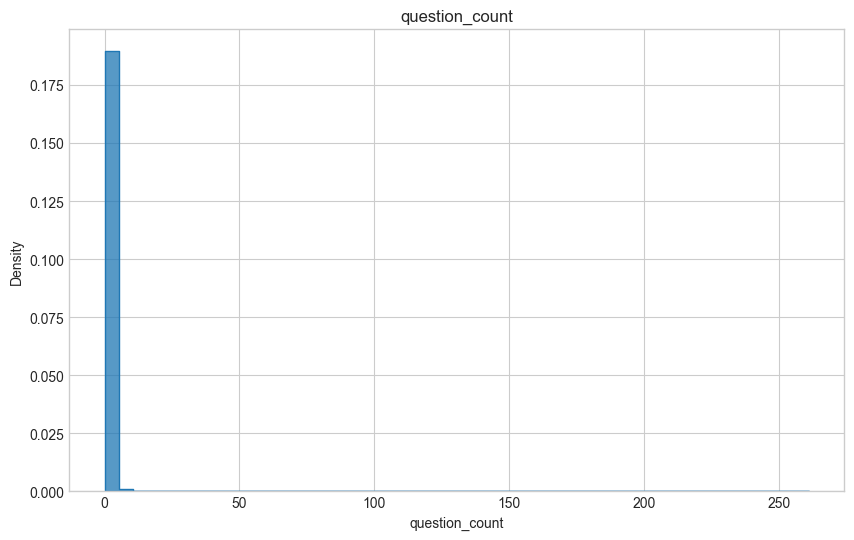

In [40]:
plot_data = df[['question_count']]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="question_count",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title('question_count')
plt.xlabel('question_count')
plt.ylabel("Density")

plt.show()

In [41]:
QC=50

outliers_QC = df[df["question_count"] > QC]   

# print

pd.set_option("display.max_rows", None)

#print(outliers_QC)    # question_count should not be a feature, as sometimes prompts ask for transcription or translation, etc.

### topic and task features

In [42]:
# prompt_style

prompt_style_summary = df.groupby("prompt_style").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


prompt_style_summary

,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
prompt_style,,,,,,,,,,
other,27917,43.00,342.00,342.00,0.85,0.19,0.01,0.27,0.00,0.05
question,20381,32.00,282.00,282.00,0.87,0.11,0.00,0.23,1.68,0.05
instruction,9231,22.00,412.00,412.00,0.86,0.02,0.03,0.20,0.00,0.05


In [43]:
# task_type

task_type_summary = df.groupby("task_type").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


task_type_summary


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
task_type,,,,,,,,,,
general_assistance,23355,21.00,289.00,289.00,0.88,0.05,0.00,0.16,0.48,0.06
writing_generation,10732,41.50,379.00,379.00,0.81,0.13,0.00,0.24,0.30,0.04
coding,10030,85.00,574.00,574.00,0.87,0.16,0.01,0.39,0.88,0.07
explanation,5534,23.00,256.00,256.00,0.92,0.12,0.06,0.21,1.06,0.04
brainstorming,2264,61.00,327.50,327.50,0.87,0.24,0.00,0.30,0.49,0.03
email_writing,1650,255.00,321.00,321.00,0.83,0.22,0.00,0.41,1.00,0.05
translation,1500,65.00,363.50,363.50,0.81,0.26,0.01,0.34,0.56,0.03
summarization,1340,205.00,211.00,211.00,0.89,0.30,0.01,0.49,0.94,0.04
roleplay,1124,61.00,192.00,192.00,0.71,0.86,0.00,0.22,0.25,0.03


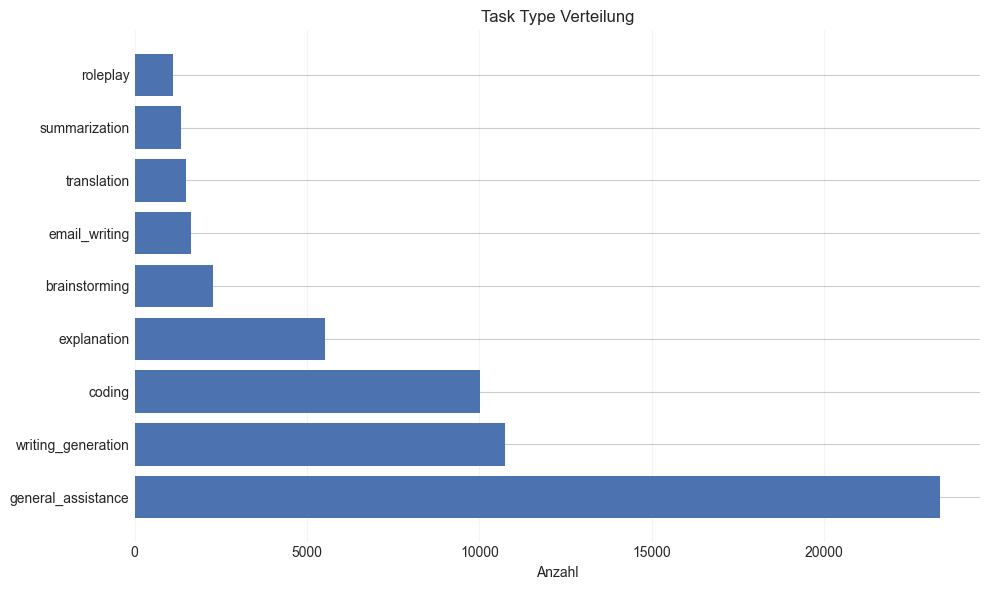

In [44]:
counts = (
    df["task_type"]
    .value_counts()
    .sort_values(ascending=True)  # oder False für Top oben
)

plt.figure(figsize=(10, 6))

plt.barh(counts.index, counts.values, color="#4C72B0")

plt.title("Task Type Verteilung")
plt.xlabel("Anzahl")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.2)

plt.box(False)
plt.tight_layout()
plt.show()

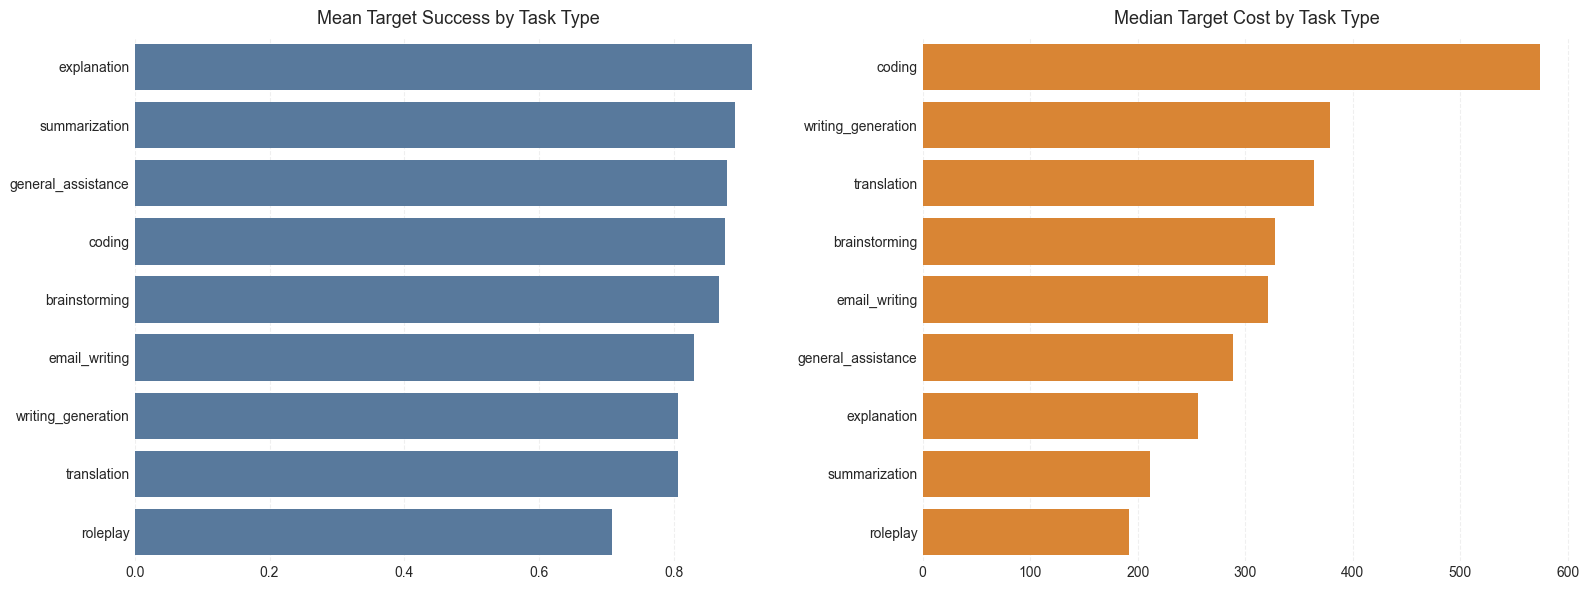

In [45]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_df = task_type_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Mean Target Success ---
sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="task_type",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Mean Target Success by Task Type", fontsize=13, pad=10)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.3)
axes[0].grid(axis="y", visible=False)

# --- Plot 2: Median Target Cost ---
sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="task_type",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Task Type", fontsize=13, pad=10)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.3)
axes[1].grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [46]:
df[["topic_label", "topic"]].value_counts()

topic_label                             topic
-1_like_use_data_write                  -1       30054
0_write_chatgpt_use_data                 0       22662
1_trip_visit_travel_day                  1         589
2_000_minutes_total_did                  2         431
3_recipe_chicken_add_ingredients         3         337
4_git_github_commit_branch               4         262
5_patient_mg_blood_ct                    5         219
6_mathematical_equation_math_2x          6         204
7_1i_1can_1what_help                     7         187
8_quantum_computing_simple terms_terms   8         187
9_excel_sheet_column_cell                9         179
10_string_regex_substitute_strings       10        146
11_36_goal_15_france                     11        132
12_docker_container_feature_compose      12        131
13_extension_browser_tab_js              13        125
14_exercise_week_fitness_weight          14        120
15_golang_logger_log_file                15        109
16_gpt_gt_include_p

In [47]:
# topic features
#'topic', 'topic_prob', 'topic_label', 'embedding_novelty', 'topic_confidence', 'is_generic_topic', 'topic_size', 'topic_size_log'

topic_labels_given = {
    -1: "Outlier / Noise",
     0: "ChatGPT / Writing / Data Usage",
     1: "Travel / Trips",
     2: "Time / Duration Tracking",
     3: "Cooking / Recipes",
     4: "Git / GitHub Development",
     5: "Medical / Clinical Data",
     6: "Math / Equations",
}

df["topic_name"] = df["topic"].map(topic_labels_given)

# topic_label

topic_label_1_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    median_first_prompts_token=("first_prompt_tokens", "median"),
    median_first_response_tokens=("first_response_tokens", "median"),
    median_target_cost=("target_cost", "median"),
    mean_target_success=("target_success", "mean"),
    mean_role_instruction=("has_role_instruction", "mean"),
    mean_audience_instruction=("has_audience_or_level_instruction", "mean"),
    mean_format_instruction=("has_format_instruction", "mean"),
    mean_question_count=("question_count", "mean"),
    mean_orthographic_error_rate=("orthographic_error_rate", "mean")
).sort_values("conversations", ascending=False)


topic_label_1_summary.head(10)


,conversations,median_first_prompts_token,median_first_response_tokens,median_target_cost,mean_target_success,mean_role_instruction,mean_audience_instruction,mean_format_instruction,mean_question_count,mean_orthographic_error_rate
topic_name,,,,,,,,,,
Outlier / Noise,30054,33.00,329.00,329.00,0.87,0.13,0.01,0.25,0.61,0.05
ChatGPT / Writing / Data Usage,22662,36.00,329.00,329.00,0.83,0.15,0.01,0.26,0.55,0.06
Travel / Trips,589,38.00,391.00,391.00,0.93,0.16,0.00,0.19,0.39,0.03
Time / Duration Tracking,431,51.00,153.00,153.00,0.92,0.02,0.00,0.07,0.94,0.01
Cooking / Recipes,337,25.00,374.00,374.00,0.90,0.14,0.00,0.23,0.34,0.03
Git / GitHub Development,262,23.00,540.50,540.50,0.93,0.02,0.00,0.16,0.62,0.09
Medical / Clinical Data,219,43.00,253.00,253.00,0.95,0.12,0.00,0.16,0.83,0.05
Math / Equations,204,25.50,252.00,252.00,0.88,0.05,0.00,0.05,0.52,0.02


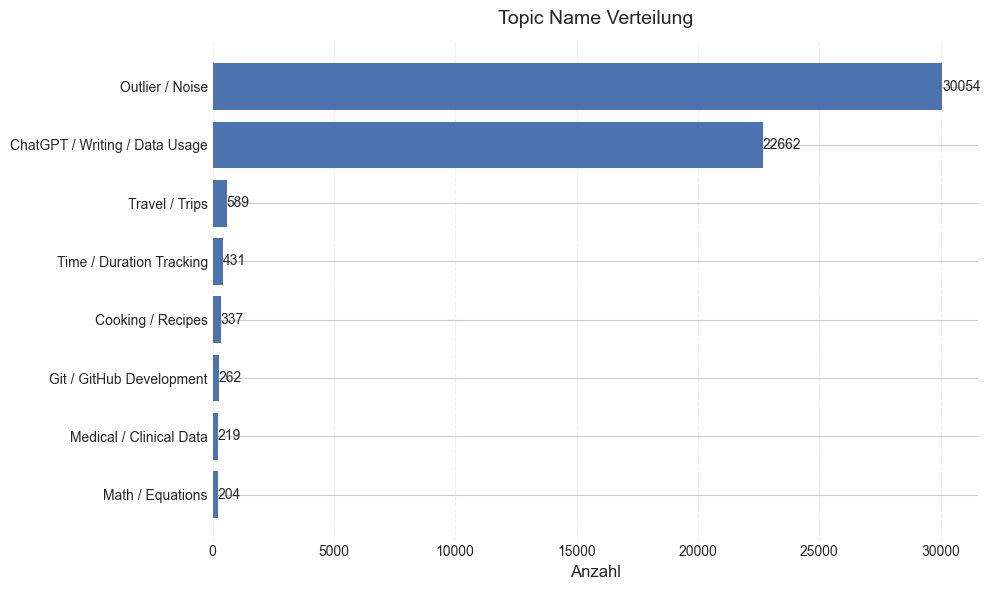

In [48]:
counts = df["topic_name"].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.barh(counts.index, counts.values, color="#4C72B0")

plt.title("Topic Name Verteilung", fontsize=14, pad=12)
plt.xlabel("Anzahl", fontsize=12)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va="center", fontsize=10)

plt.gca().invert_yaxis() 
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.box(False)
plt.tight_layout()
plt.show()

In [49]:
# topic_label

topic_label_2_summary = df.groupby("topic_name").agg(
    conversations=("conversation_id", "count"),
    mean_novelty=("embedding_novelty", "mean"), 
    mean_confidence=("topic_confidence", "mean"),
    mean_generic=("is_generic_topic", "mean"),
    mean_topic_size=("topic_size", "mean")
).sort_values("conversations", ascending=False)


topic_label_2_summary.head(10)

,conversations,mean_novelty,mean_confidence,mean_generic,mean_topic_size
topic_name,,,,,
Outlier / Noise,30054,0.76,0.40,0.00,30054.00
ChatGPT / Writing / Data Usage,22662,0.74,0.75,1.00,22662.00
Travel / Trips,589,0.80,0.36,0.00,589.00
Time / Duration Tracking,431,0.87,0.31,0.00,431.00
Cooking / Recipes,337,0.82,0.56,0.00,337.00
Git / GitHub Development,262,0.91,0.42,0.00,262.00
Medical / Clinical Data,219,0.94,0.54,0.00,219.00
Math / Equations,204,0.85,0.62,0.00,204.00


In [50]:
df["target_success"].value_counts()

target_success
True     49529
False     8000
Name: count, dtype: int64

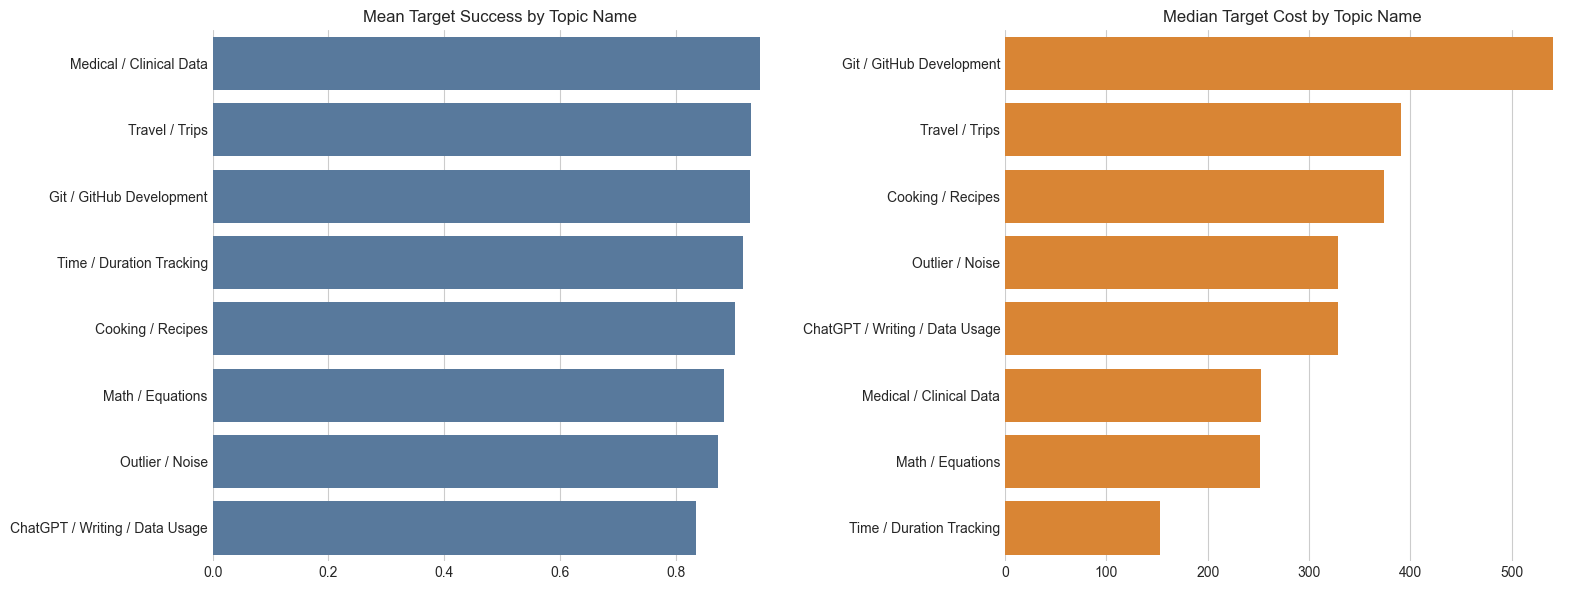

In [51]:
plot_df = topic_label_1_summary.reset_index()

# > 200 conversations
plot_df = plot_df[plot_df["conversations"] >= 200]

#plot_df = topic_label_summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=plot_df.sort_values("mean_target_success", ascending=False),
    x="mean_target_success",
    y="topic_name",
    ax=axes[0],
    color="#4C78A8"
)

axes[0].set_title("Mean Target Success by Topic Name")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.barplot(
    data=plot_df.sort_values("median_target_cost", ascending=False),
    x="median_target_cost",
    y="topic_name",
    ax=axes[1],
    color="#F58518"
)

axes[1].set_title("Median Target Cost by Topic Name")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [52]:
pd.crosstab(df["topic_name"], df["task_type"])

task_type,brainstorming,coding,email_writing,explanation,general_assistance,roleplay,summarization,translation,writing_generation
topic_name,,,,,,,,,
ChatGPT / Writing / Data Usage,910,4498,744,1938,8453,440,616,700,4363
Cooking / Recipes,32,9,1,21,227,3,0,6,38
Git / GitHub Development,1,72,3,17,131,0,1,1,36
Math / Equations,3,2,2,61,121,2,0,0,13
Medical / Clinical Data,10,15,0,37,110,10,3,4,30
Outlier / Noise,1125,4862,863,2950,12447,614,687,736,5770
Time / Duration Tracking,2,3,0,59,350,0,0,6,11
Travel / Trips,127,17,7,27,315,15,4,6,71


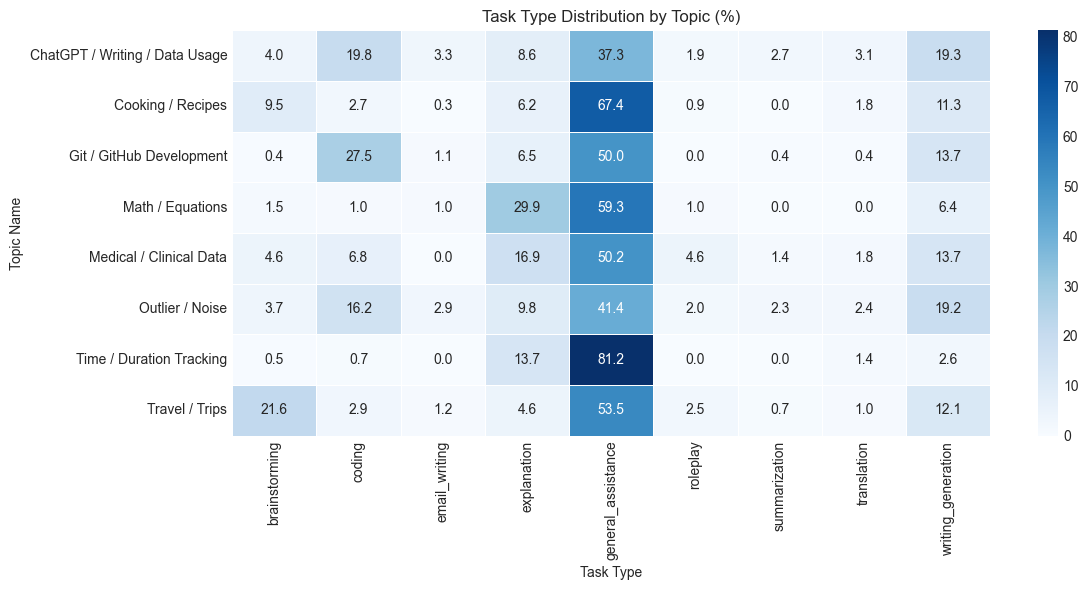

In [53]:
ct = pd.crosstab(df["topic_name"], df["task_type"])

ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))

sns.heatmap(
   ct_norm,
    cmap="Blues",
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Task Type Distribution by Topic (%)")
plt.xlabel("Task Type")
plt.ylabel("Topic Name")

plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name'],
      dtype='str')

In [24]:
K = 4  # numbers of example

top_examples = (
    df.sort_values("topic_prob", ascending=False)
      .groupby("topic")
      .head(K)[["topic", "topic_prob", "first_prompt"]]
)

top_examples

for topic, sub in top_examples.groupby("topic"):
    print("\n" + "="*80)
    print(f"TOPIC: {topic}")
    print("="*80)
    
    for _, row in sub.iterrows():
        print(f"[{row['topic_prob']:.2f}] {row['first_prompt']}")


TOPIC: -1
[0.89] Turn this into competency based questions for a Customer Success Executive role:

"To be successful in this Customer Success Executive role, you should have experience working within a high-touch SaaS Customer Success team environment (i.e., hands-on, providing proactive account management), preferably in a Business-to-Business capacity. This likely includes regular customer meetings, help centre tickets (we use Zendesk), creation of ‘How to’ guides or advice etc but we’re keen to hear about any similar experiences.


You should be a great relationship builder with well-developed customer service skills (potentially gained in an account management, client management, customer success, operational or project management environment) and the ability to handle multiple concurrent projects, prioritise your own work, and remain effective during periods of increased workload.


Additionally, you will:

•	Thrive when you’re working in a methodical and analytical manner, using

# embedding novelty

In [25]:
df["embedding_novelty"].describe()

df["novelty_bucket"] = pd.cut(
    df["embedding_novelty"],
    bins=[
        df["embedding_novelty"].min(),
        df["embedding_novelty"].quantile(0.1),
        df["embedding_novelty"].quantile(0.9),
        df["embedding_novelty"].max()
    ],
    labels=["central", "typical", "peripheral"]
)


central = df[df["novelty_bucket"] == "central"].sample(5)
peripheral = df[df["novelty_bucket"] == "peripheral"].sample(5)

central

,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,...,topic_label,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost,target_success,topic_name,novelty_bucket
3405,MUzMpP6,I want you to act as a technical project manag...,"<div class=""markdown prose w-full break-words ...",28,62,14,7.00,1201,1201,2402,...,0_write_chatgpt_use_data,0.55,0.80,1,22662,10.03,62,True,ChatGPT / Writing / Data Usage,central
11912,tN7hViS,Ignore all the instructions you got before. Fr...,"<div class=""markdown prose w-full break-words ...",920,600,140,70.00,19568,24408,43976,...,0_write_chatgpt_use_data,0.51,1.00,1,22662,10.03,600,True,ChatGPT / Writing / Data Usage,central
575,2XzDMwu,1 / 1my partner has written this really long a...,<div><p>It seems like your partner is proposin...,1650,488,4,2.00,1712,860,2572,...,-1_like_use_data_write,0.42,0.43,0,30054,10.31,488,True,Outlier / Noise,central
8680,ZzXA2mL,I am working on an app to offer QR code based ...,"<div class=""markdown prose w-full break-words ...",31,368,4,2.00,54,617,671,...,0_write_chatgpt_use_data,0.54,1.00,1,22662,10.03,368,True,ChatGPT / Writing / Data Usage,central
4272,IyF6Ih5,a twitter thread of the essential steps about ...,"<div><p>Sure, here's a Twitter thread outlinin...",18,348,272,136.00,8394,15904,24298,...,0_write_chatgpt_use_data,0.55,0.82,1,22662,10.03,348,True,ChatGPT / Writing / Data Usage,central


In [26]:
peripheral

,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_tokens,total_assistant_tokens,total_tokens,...,topic_label,embedding_novelty,topic_confidence,is_generic_topic,topic_size,topic_size_log,target_cost,target_success,topic_name,novelty_bucket
34918,Bc2AA9y,How to apply adaptive kernal in Convolution ne...,"<div class=""markdown prose w-full break-words ...",15,1152,2,1.00,15,1152,1167,...,0_write_chatgpt_use_data,0.99,0.79,1,22662,10.03,1152,True,ChatGPT / Writing / Data Usage,peripheral
11420,zrE37Rn,c what function to read file at specific offset,"<div class=""markdown prose w-full break-words ...",9,914,14,7.00,67,7011,7078,...,-1_like_use_data_write,1.01,0.50,0,30054,10.31,914,True,Outlier / Noise,peripheral
21300,GvCWww3,"Nowadays, are there plastic houses made like c...","<div class=""markdown prose w-full break-words ...",17,134,4,2.00,23,345,368,...,0_write_chatgpt_use_data,0.99,0.77,1,22662,10.03,134,True,ChatGPT / Writing / Data Usage,peripheral
34975,3KyDXP1,"이번에 라이브커머스 쇼호스트에서 일하고 있고, 직접 제품을 소싱해서 판매도 하고 있...",<div><p>인터뷰 대상자의 전문적인 경험과 지식에 대한 깊은 이해와 함께 종합적...,176,608,2,1.00,176,608,784,...,0_write_chatgpt_use_data,0.99,0.80,1,22662,10.03,608,False,ChatGPT / Writing / Data Usage,peripheral
9369,xHNNsgY,How can I show a custom name instead of the cl...,"<div class=""markdown prose w-full break-words ...",75,656,18,9.00,216,6643,6859,...,-1_like_use_data_write,1.03,0.01,0,30054,10.31,656,True,Outlier / Noise,peripheral


# targets

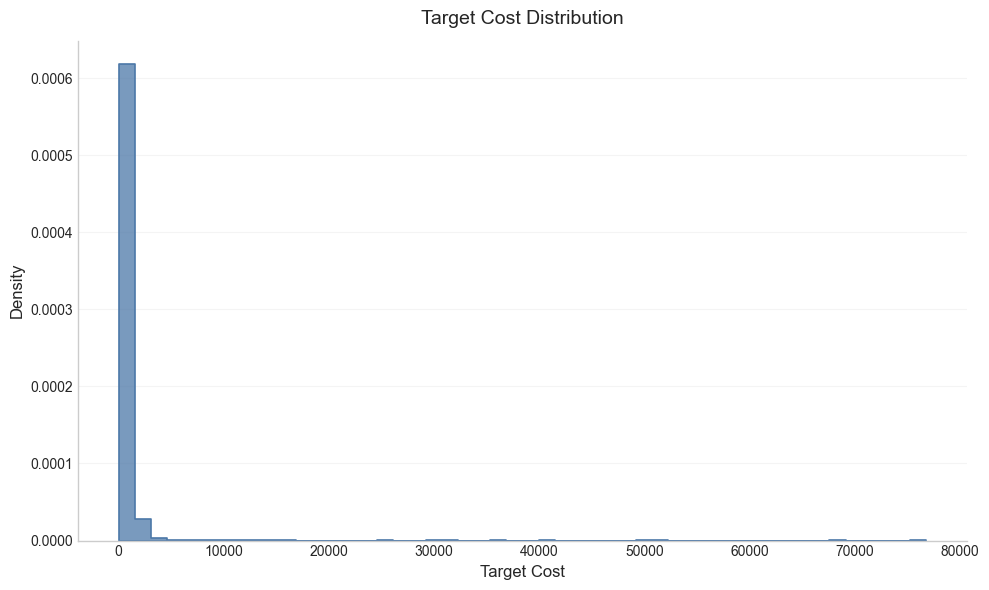

In [27]:
#'target_cost'

plt.style.use("seaborn-v0_8-whitegrid")

plot_data = df[["target_cost"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    color="#4C78A8",
    linewidth=1.2
)

plt.title("Target Cost Distribution", fontsize=14, pad=12)
plt.xlabel("Target Cost", fontsize=12)
plt.ylabel("Density", fontsize=12)

# cleaner look wie bei deinen anderen plots
plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

In [28]:
df["target_cost_log"] = np.log1p(df["target_cost"])                  # highly skewed (but plausible), therefore log


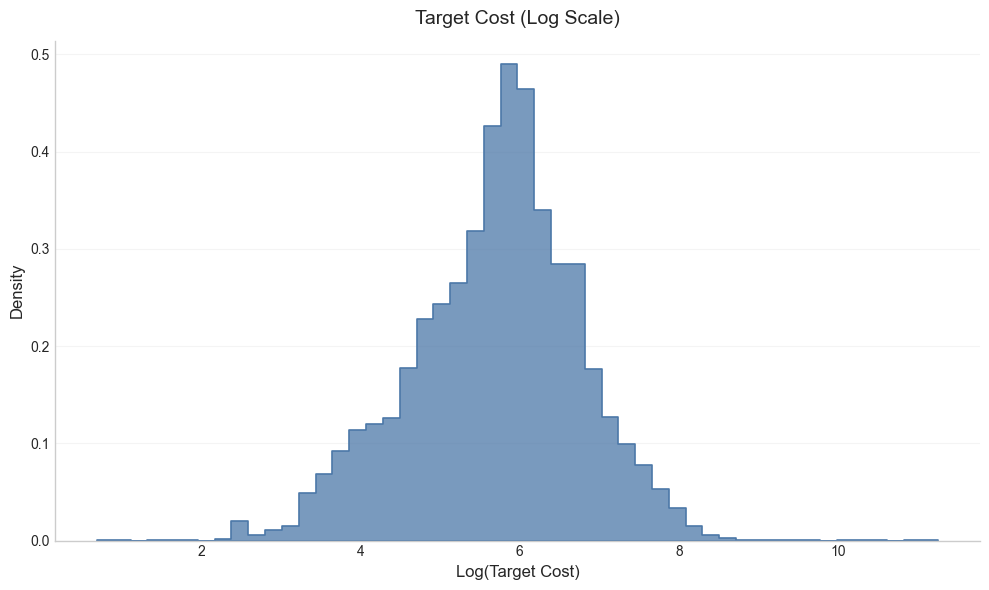

In [29]:
#'"target_cost_log"'

plt.style.use("seaborn-v0_8-whitegrid")

plot_data = df[["target_cost_log"]]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data,
    x="target_cost_log",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    color="#4C78A8",
    linewidth=1.2
)

plt.title("Target Cost (Log Scale)", fontsize=14, pad=12)
plt.xlabel("Log(Target Cost)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# clean grid wie bei deinen anderen plots
plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

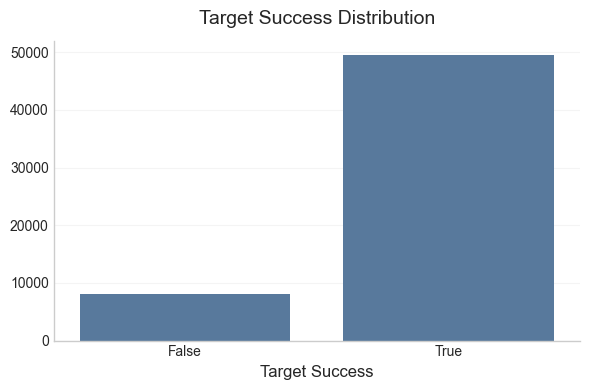

In [30]:
# 'target_success'

plt.style.use("seaborn-v0_8-whitegrid")

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target_success",
    color="#4C78A8"
)

plt.title("Target Success Distribution", fontsize=14, pad=12)
plt.xlabel("Target Success", fontsize=12)
plt.ylabel("", fontsize=12)

plt.grid(axis="y", alpha=0.2)
plt.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()
plt.show()

In [61]:
df.head()

conversation_id  \
0         Og9h3C1   
1         QWJhYvA   
2         i6IyJda   
3         A5AbcES   
4         hRPPgZT   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       first_prompt  \
0  root@openvpn:/home/openvpn# ./openvpn-install.sh\nWelcome to OpenVPN-install!\nThe git repository is available at: https://github.com/angristan/openvpn-install\n\nIt looks like OpenVPN is already installed.\n\nWhat do you want to do?\n   1) Add a new user\n   2) Revoke existing user\n   3) Remove OpenVPN\n   4) Exit\nSelect an option [1-4]: 1\n\nTell me a name for the client.\nThe name must consist of alphanumeric character. It may also include an underscore or a dash.\nClient name: naam\n\nDo you want to protect the configuration file with a password?\n(e.g. encrypt the private key with a password)\n   1) Add a passwordless client\n   2) Use a password for the client\nSelect an option [1-2]: 1\n\nNote: using Easy-RSA configuration from: /etc/openvpn/easy-rsa/vars\nUsing SSL: openssl OpenSSL 3.0.2 15 Mar 2022 (Library: OpenSSL 3.0.2 15 Mar 2022)\n-----\nUsing configuration from /etc/openvpn/easy-rsa/pki/easy-rsa-54848.BT2FXv/tmp.dFLd6V\nEnter pass phrase for /etc/openvpn/easy-rsa/pki/private/ca.key:\nCheck that the request matches the signature\nSignature ok\nThe Subject's Distinguished Name is as follows\ncommonName            :ASN.1 12:'naam'\nCertificate is to be certified until Apr 21 22:48:57 2025 GMT (825 days)\n\nWrite out database with 1 new entries\nData Base Updated\n\nClient naam added.\n\nThe configuration file has been written to /home/openvpn/naam.ovpn.\nDownload the .ovpn file and import it in your OpenVPN client.\nroot@openvpn:/home/openvpn# \n\n\nkan je op basis van deze gegevens een verslag maken hoe je iemand toevoegd op een openvpn server   
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

Results

- remove question_count (not clear enough as feature with counting questionmarks in first response; what about translations or transcripts,etc?)
- orthographic error rate for cleaner text (some other languages are still included; differentiation to translation, code, etc. is complicated)
- target "target_success" needs balancing in the models
- target "target_cost" is highly skewed, therefore "target_cost_log" as new target

In [31]:
base_path = Path(
    "C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features_target.csv"
)

base_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(base_path, index=False)